# K-Nearest Neigbors (KNN)

The entire soul of kNN in one sentence: **the closest points matter most, distant points shouldn't get a vote at all.**

So here's the natural next step. Instead of weighting all 20 dots by closeness (which gets mathematically messy fast), what if we did something simpler: **just pick a small number of the closest dots — say the 3 closest — completely ignore everyone else, and let those 3 "vote"** on Pass/Fail by majority?

That's it. That's k-Nearest Neighbors. The "k" is just "how many closest neighbors get a vote." k=3 means look at the 3 nearest students, see how many Passed vs Failed among just those 3, go with the majority.

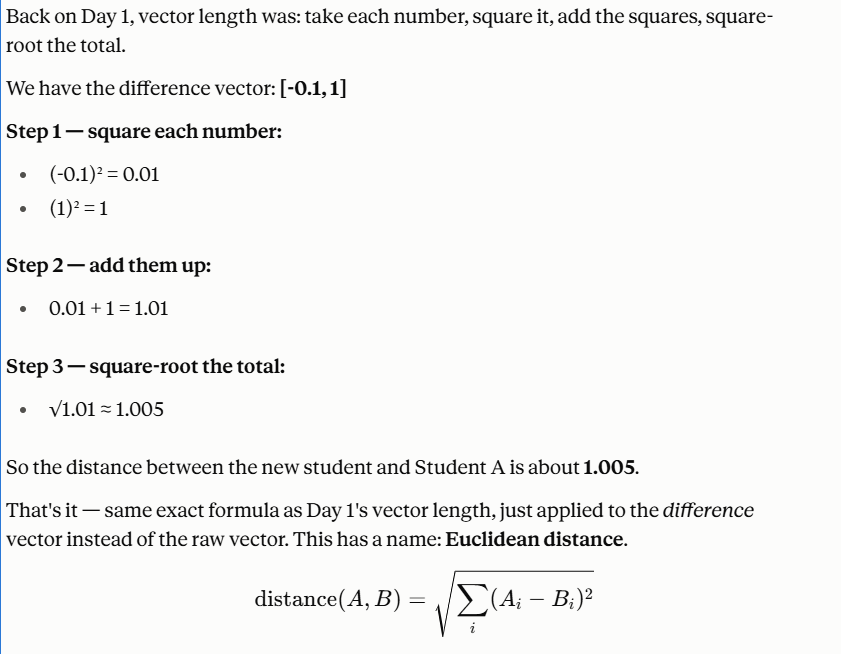

**The full kNN recipe:**

1. **Choose k** (e.g. k=3) — decided before you even look at the new point
2. **Compute the distance** from the new point to every single point in the training set (using Euclidean distance)
3. **Sort** those distances from smallest to largest
4. Take the top k closest points (ignore everyone else, no matter how many training points you have)
5. **Majority vote** among those k neighbors' labels → that's your prediction

Notice something important: **there's no fit() in the traditional sense.** No weights are learned, no gradient descent, no loss function minimized. "Training" a kNN model just means storing the training data. All the real work happens at prediction time.

This has a name — kNN is called a "**lazy learner**" or **instance-based method**, as opposed to Linear/Logistic Regression which are "eager learners" that do all their work upfront during fit() and then predict cheaply.

In [47]:
import numpy as np

# hours studied, attendance %
X_train = np.array([
    [1, 45],
    [2, 50],
    [2, 55],
    [3, 60],
    [4, 58],
    [5, 90],
    [6, 55],   # <- the "tricky" student: decent hours, but low attendance -> Failed
    [7, 85],
    [8, 90],
    [9, 95],
])

y_train = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1])  # 0=Fail, 1=Pass

In [48]:
def euclidean_distance(point1, point2):
    diff = point1 - point2  # difference of the vectors
    squared = diff**2       # squaring the difference
    total = np.sum(squared) # Sum up the squared values
    return np.sqrt(total)

p1 = np.array([6, 55])
p2 = np.array([4, 58])
print(euclidean_distance(p1, p2))

3.605551275463989


In [49]:
# Step 1 — distances to every training point.

def get_distance(new_point, X_train):
    distances = []
    for i in range(len(X_train)):
        d = euclidean_distance(new_point, X_train[i])
        distances.append(d)
    return distances

In [50]:
new_point = np.array([6, 55])
distances = get_distance(new_point, X_train)
print(distances)

[np.float64(11.180339887498949), np.float64(6.4031242374328485), np.float64(4.0), np.float64(5.830951894845301), np.float64(3.605551275463989), np.float64(35.014282800023196), np.float64(0.0), np.float64(30.01666203960727), np.float64(35.05709628591621), np.float64(40.11234224026316)]


In [51]:
def predict_one(new_point, X_train, y_train, k):
    distances = get_distance(new_point, X_train)
    sorted_indices = np.argsort(distances)
    k_nearest_indices = sorted_indices[:k]
    k_nearest_labels = y_train[k_nearest_indices]

    # majority vote
    counts = np.bincount(k_nearest_labels)
    prediction = np.argmax(counts)
    return prediction

In [52]:
prediction = predict_one(new_point = np.array([6, 55]), X_train=X_train, y_train=y_train, k=3)
print(prediction)

0


In [53]:
# In case we have 5 new points that needs to be predicted

def predict(X_new, X_train, y_train, k):
    predictions = []
    for i in range(len(X_new)):
        pred = predict_one(X_new[i], X_train, y_train, k)
        predictions.append(pred)
    return np.array(predictions)

In [54]:
X_test = np.array([
    [6, 55],   # tricky student - should predict Fail (0)
    [8, 92],   # clearly high on both - should predict Pass (1)
    [2, 48],   # clearly low on both - should predict Fail (0)
])

predictions = predict(X_test, X_train, y_train, k=3)
print(predictions)

[0 1 0]


#### Verify our from-scratch implementation against sklearn

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn_sklearn = KNeighborsClassifier(n_neighbors=3)
knn_sklearn.fit(X_train, y_train)
sklearn_predictions = knn_sklearn.predict(X_test)

print("Scratch:  ", predictions)
print("sklearn:  ", sklearn_predictions)
print("Match:    ", np.array_equal(predictions, sklearn_predictions))

Scratch:   [0 1 0]
sklearn:   [0 1 0]
Match:     True


For kNN, .fit(X_train, y_train) does **almost nothing** — it just **stores** X_train and y_train in memory (maybe builds a lookup structure like a KD-tree for speed, but conceptually: just remembers the data). It **does not** compute any distances yet, and it definitely doesn't run our full recipe yet.

The actual recipe — compute distances, sort, pick k, vote — only runs later, inside .predict(X_test), one new point at a time. That's the "lazy learner" idea from earlier: all the real work is postponed until prediction time.

Compare this to Logistic Regression's .fit(): that one actually does real work upfront — gradient descent, iterating hundreds of times, converging on a weight vector w. Once that's done, .predict() is cheap (sigmoid(X_b @ w)), because all the "learning" already happened and got compressed into w.

So the split is:
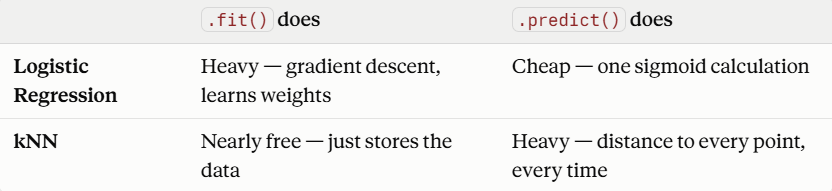

**With k=1**: the prediction is always exactly the label of the single closest training point — no averaging, no smoothing at all. This means the model is extremely sensitive to noise. If even one training point is mislabeled or is an outlier, any new point that happens to land near it will inherit that possibly-wrong label directly, with zero "second opinion" from other nearby points.

**With k = entire training set:** every single prediction, for any new point anywhere, ends up voting across the entire dataset — meaning the result is just whichever class is more common overall. Position in space stops mattering at all; you'd get the exact same prediction for a new student at [1,45] and one at [9,95]. The model degenerates into "always predict the majority class," completely ignoring the new point's actual location.

This is a real bias-variance tradeoff, same family of idea as Ridge/Lasso's regularization strength:

1. **Small k (like k=1):** low bias, high variance — very flexible, hugs the training data tightly, but overfits to noise
2. **Large k:** high bias, low variance — very smooth, stable, but underfits and ignores real local patterns

**Quick recap of everything we've built for kNN so far:**

1. Euclidean distance from scratch (Day 1's Pythagoras, applied to a difference vector)
2. Full predict-one recipe: distance → sort (argsort) → take k nearest → majority vote (bincount + argmax)
3. Verified exactly against sklearn
4. Diagnosed and fixed the feature-scaling trap (same canyon problem as Day 6/9, different mechanism)
5. Explored the bias-variance tradeoff across k values, with a real F1 sweep showing the k=1→k=84 spectrum
6. Wrapped it all into a clean, reusable class

**Non-parametric — what it actually means**

"**Parametric**" models (Linear/Logistic/Softmax Regression) learn a fixed number of parameters — a weight vector w — regardless of how much training data you have. Once trained, the training data itself can be thrown away; only w matters.

kNN is **non-parametric**: there's no fixed-size w at all. The "model" is the training data itself — all of it, kept around perm* anently. As you add more training points, the model literally grows in size and complexity. There's no compression step, no fixed number of parameters to learn.

This is why kNN's prediction cost grows with data size (as we discussed) — it's fundamentally a different kind of model, not just "a model that happens to be slow."

**Common mistakes**

* Forgetting to scale features before distance calculations (today's canyon trap)
* Using an even k in binary classification (risking tie votes)
* Picking k=1 blindly — extremely sensitive to noisy/mislabeled points
* Not realizing prediction gets slower as training data grows — a real production bottleneck at scale
* Using Euclidean distance blindly on categorical or very high-dimensional data, where "distance" starts to lose meaning (the curse of dimensionality — worth just naming for now)

# Naive Bayes

Now let's name the actual pieces we just computed, because they map directly onto Bayes' Theorem's formula:

* P(Disease) = 1% → the "prior" — what you believed before seeing any test result, just from the population
* P(Positive | Disease) = 90% → "likelihood" — given you're sick, chance of a positive test
* P(Positive) = 59/1000 = 5.9% → overall chance of testing positive, sick or not
* P(Disease | Positive) = 9/59 ≈ 15% → the "posterior" — what you actually want: given a positive test, what's the updated belief about having the disease?

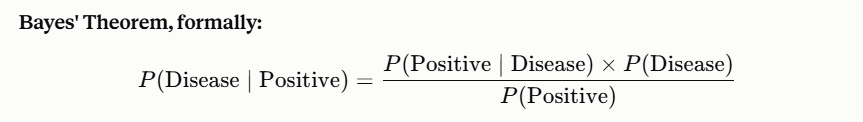

Now here's the bridge to classification. Replace "Disease" with "Class label" (e.g. Pass/Fail), and replace "Positive test" with "the features we observe" (e.g. hours=6, attendance=55). Bayes' Theorem becomes:

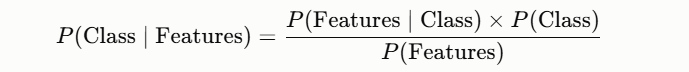

**P(Class | Features)** reads as: **"given that I've observed THESE specific features (hours=6, attendance=55), what's the probability this student's class is Pass? What's the probability it's Fail?"** It's asking for the probability of the label, conditioned on the specific data point in front of you.

Once we compute this for **both** classes — say we get P(Pass | features) = 0.72 and P(Fail | features) = 0.28 — the natural next step is: **predict whichever class has the higher probability.** Just like kNN's majority vote, or Logistic Regression's 0.5 cutoff, this is the final decision rule: pick the class that Bayes' Theorem says is more likely, given what you observed.

#### First, the Gaussian probability density function

In [56]:
import numpy as np

def gaussian_pdf(x, mean, std):
    exponent = ((x - mean) ** 2) / (2 * std ** 2)
    coefficient = 1 / np.sqrt(2 * np.pi * std ** 2)
    return coefficient * np.exp(exponent)

In [57]:
# Example -
mean, std = 7.14, 1.2

print('x=7.14 (at the mean)  ->', gaussian_pdf(7.14, mean, std))
print('x=8.0  (close-ish)    ->', gaussian_pdf(8.0, mean, std))
print('x=10.0 (farther)      ->', gaussian_pdf(10.0, mean, std))
print('x=20.0 (way outside)  ->', gaussian_pdf(20.0, mean, std))

x=7.14 (at the mean)  -> 0.3324519003345272
x=8.0  (close-ish)    -> 0.4297917308696636
x=10.0 (farther)      -> 5.690959134608168
x=20.0 (way outside)  -> 2.8868614264184133e+24


**Now let's build the full Gaussian Naive Bayes classifier. The recipe is:**

1. Split training data by class (all Pass students, all Fail students)
2. For each class, compute mean and std of each feature (separately per class)
3. Also compute P(Class) — the prior — just the fraction of training data belonging to that class
4. For a new point, compute P(feature₁|Class) × P(feature₂|Class) × ... × P(Class) for each class
Predict whichever class gives the highest result

In [58]:
# Piece 1 — the Gaussian PDF function as derived above

# Piece 2 — reuse our same dataset:

X_train = np.array([
    [1, 45],
    [2, 50],
    [2, 55],
    [3, 60],
    [4, 58],
    [5, 90],
    [6, 55],
    [7, 85],
    [8, 90],
    [9, 95],
])
y_train = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1])

In [59]:
mask_fail = (y_train == 0)
print(mask_fail)

[ True  True  True  True  True False  True False False False]


In [60]:
X_fail = X_train[mask_fail]
print(X_fail)

[[ 1 45]
 [ 2 50]
 [ 2 55]
 [ 3 60]
 [ 4 58]
 [ 6 55]]


In [61]:
mask_pass = (y_train == 1)
X_pass = X_train[mask_pass]
print(X_pass)

[[ 5 90]
 [ 7 85]
 [ 8 90]
 [ 9 95]]


In [62]:
mean_fail = X_fail.mean(axis=0)
std_fail = X_fail.std(axis=0)

mean_pass = X_pass.mean(axis=0)
std_pass = X_pass.std(axis=0)

print("Fail  - mean:", mean_fail, " std:", std_fail)
print("Pass  - mean:", mean_pass, " std:", std_pass)

Fail  - mean: [ 3.         53.83333333]  std: [1.63299316 5.01386965]
Pass  - mean: [ 7.25 90.  ]  std: [1.47901995 3.53553391]


In [63]:
prior_fail = len(X_fail) / len(X_train)
prior_pass = len(X_pass) / len(X_train)

print("Prior Fail:", prior_fail)
print("Prior Pass:", prior_pass)

Prior Fail: 0.6
Prior Pass: 0.4


In [64]:
new_point = np.array([6, 55])

log_score_fail = np.log(prior_fail)
log_score_fail += np.log(gaussian_pdf(new_point[0], mean_fail[0], std_fail[0]))
log_score_fail += np.log(gaussian_pdf(new_point[1], mean_fail[1], std_fail[1]))

log_score_pass = np.log(prior_pass)
log_score_pass += np.log(gaussian_pdf(new_point[0], mean_pass[0], std_pass[0]))
log_score_pass += np.log(gaussian_pdf(new_point[1], mean_pass[1], std_pass[1]))

print('log_score_fail:', log_score_fail)
print('log_score_pass:', log_score_pass)

log_score_fail: -2.7367534960986877
log_score_pass: 44.9487310670804


#### Piece 1 — the class skeleton and fit():

In [68]:
import numpy as np

def gaussian_pdf(x, mean, std):
    exponent = -((x - mean) ** 2) / (2 * std ** 2)
    coefficient = 1 / np.sqrt(2 * np.pi * std ** 2)
    return coefficient * np.exp(exponent)

class GaussianNaiveBayesScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.stds = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = X_c.mean(axis=0)
            self.stds[c] = X_c.std(axis=0)
            self.priors[c] = len(X_c) / len(X)

        return self

# Piece 2 — predicting one point:
    def _predict_one(self, x):
        scores = {}
        for c in self.classes:
            log_score = np.log(self.priors[c])
            for i in range(len(x)):
                log_score += np.log(gaussian_pdf(x[i], self.means[c][i], self.stds[c][i]))
            scores[c] = log_score
        return max(scores, key=scores.get)

# Last piece — the public predict() method that loops over multiple new points:

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])

X_train = np.array([
    [1, 45],[2, 50],[2, 55],[3, 60],[4, 58],
    [5, 90],[6, 55],[7, 85],[8, 90],[9, 95],
])
y_train = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1])

X_test = np.array([[6, 55],[8, 92],[2, 48]])

model = GaussianNaiveBayesScratch().fit(X_train, y_train)
predictions = model.predict(X_test)
print('Scratch predictions:', predictions)

Scratch predictions: [0 1 0]


### Verify against sklearn's GaussianNB:

In [69]:
from sklearn.naive_bayes import GaussianNB

nb_sklearn = GaussianNB()
nb_sklearn.fit(X_train, y_train)
sklearn_predictions = nb_sklearn.predict(X_test)

print("Scratch:  ", predictions)
print("sklearn:  ", sklearn_predictions)
print("Match:    ", np.array_equal(predictions, sklearn_predictions))

Scratch:   [0 1 0]
sklearn:   [0 1 0]
Match:     True


In [70]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report

np.random.seed(42)

# same imbalanced dataset as Day 13
X0 = np.random.randn(300, 2) * 1.5 + [0, 0]
X1 = np.random.randn(15, 2) * 1.0 + [3, 3]
X2 = np.random.randn(8, 2) * 1.0 + [-3, 3]

X = np.vstack([X0, X1, X2])
y = np.array([0]*300 + [1]*15 + [2]*8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# scale for kNN (Gaussian NB doesn't need scaling - it works per-feature independently)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

# --- Model 1: kNN ---
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)
pred_knn = knn.predict(X_test_scaled)

# --- Model 2: Gaussian Naive Bayes ---
gnb = GaussianNB()
gnb.fit(X_train, y_train)
pred_gnb = gnb.predict(X_test)

print("=== kNN (k=15) ===")
print("Confusion matrix:\n", confusion_matrix(y_test, pred_knn))
print(f"Macro F1:    {f1_score(y_test, pred_knn, average='macro'):.4f}")
print(f"Micro F1:    {f1_score(y_test, pred_knn, average='micro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, pred_knn, average='weighted'):.4f}")

print("\n=== Gaussian Naive Bayes ===")
print("Confusion matrix:\n", confusion_matrix(y_test, pred_gnb))
print(f"Macro F1:    {f1_score(y_test, pred_gnb, average='macro'):.4f}")
print(f"Micro F1:    {f1_score(y_test, pred_gnb, average='micro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, pred_gnb, average='weighted'):.4f}")

=== kNN (k=15) ===
Confusion matrix:
 [[90  0  0]
 [ 3  2  0]
 [ 2  0  0]]
Macro F1:    0.5148
Micro F1:    0.9485
Weighted F1: 0.9322

=== Gaussian Naive Bayes ===
Confusion matrix:
 [[90  0  0]
 [ 1  4  0]
 [ 1  0  1]]
Macro F1:    0.8482
Micro F1:    0.9794
Weighted F1: 0.9772


**Does either model have a class_weight='balanced' equivalent?**

* **sklearn's GaussianNB** actually does have a priors parameter — you can manually pass in custom class priors instead of letting it estimate them from raw training-data frequency. So if you know your rare class is under-represented purely due to sampling (not because it's actually rare in the real world), you could hand-set a more balanced prior. This is conceptually similar to class_weight='balanced', though you'd have to compute the balancing yourself rather than getting an automatic one-line fix.

* **sklearn's KNeighborsClassifier** has no class_weight parameter at all — because kNN doesn't have a loss function to reweight in the first place (remember, there's no training/optimization step). The closest lever you have is weights='distance' — instead of every neighbor getting an equal vote, closer neighbors get more voting weight than farther ones. That doesn't fix class imbalance directly, but it can help slightly, since it reduces the "diluted by distant majority-class neighbors" problem we diagnosed. The real fix for kNN's imbalance weakness would be Day 13's resampling approach (oversampling the rare class, or undersampling the majority) — since kNN has no internal loss to reweight, you have to fix it at the data level instead.

This is a genuinely important, interview-worthy distinction: **algorithms with a loss function (Logistic Regression, Naive Bayes via priors) can be rebalanced by reweighting the loss itself; algorithms without one (kNN) require fixing the data distribution directly** — which is exactly why Day 13 named resampling as a "data-level, not algorithm-level" alternative in the first place. Today's result gives that abstract idea a concrete, measured example.